Nombre del alumno:

In [1]:
# Marino Chimal Uscanga

Notebook original: https://www.kaggle.com/code/anubhabswain/iris-classification-logistic-regression/notebook

# Clasificación de Iris por medio de Regresión Lógistica

El iris dataset es un famoso conjunto de datos publicado en 1936 por el estadístico y biólogo británico **Ronald Ayler Fisher**.
Él quería responder una pregunta muy sencilla:


  **¿Es posible identificar automáticamente la especie de una flor únicamente observando algunas de sus medidas?**


Fisher registró 150 observaciones de tres tipos de especies de flores

*   **Iris Setosa**
*   **Iris Versicolor**
*   **Iris Virginica**

Dentro del dataset cada especie tiene exactamente 50 muestras por lo que está perfectamente balanceado, cada observación corresponde a una flor que fue medida físicamente.

Se realizaron cuatro mediciones (features) para cada flor y son las siguientes:

*   **Sepal Length** - Longitud del sépalo
*   **Sepal Width** - Ancho de sépalo
*   **Petal Length** - Longitud del pétalo
*   **Petal Width** - Ancho del pétalo

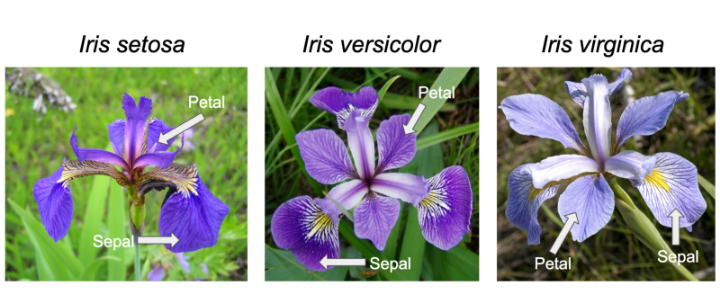

**Regresión Lógistica**


Ecuación matématica:

$$z = w_1 x_1 + w_2 x_2 + w_3 x_3 + w_4 x_4 + b$$

Los $x$ son las características (features), en Iris:

$$x_1 = SepalLength$$
$$x_2 = SepalWidth$$
$$x_3 = PetalLength$$
$$x_4 = PetalWidth$$

Los $w$ son las pesos, los aprende el modelo, al inicio no sabe cuales son.

El $b$ es el bias o intercepto, es un ajuste fino.

El resultado de aplicar la ecuación nos entrega un número que es una combinación lineal de características.

A este número resultante se le aplica una función logística conocida cómo **Sigmoide o Softmax** que toma cualquier número real y lo convierte en un valor entre 0 y 1.
Donde los valores cercanos a 0 tienen muy poca probabilidad de pertenecer a una clase y los valores cercanos a 1 una alta probabilidad.

Pero si la función Sigmoide sólo produce una probabilidad ¿cómo clasifica tres especies?

La regresión logística utilizada por scikit-learn extiende el modelo para clasificación multiclase mediante un esquema llamado One-vs-Rest (OvR) o mediante una formulación multinomial con Softmax, dependiendo de la configuración y del solver. En ambos casos, el objetivo es calcular probabilidades para las tres clases y elegir la de mayor probabilidad.

## Importación de Librerías

In [2]:
# Se importa la biblioteca NumPy y le asigna el alias np
import numpy as np
# Se importa la biblioteca Pandas y le asigna el alias pd
import pandas as pd
# Importamos el modelo de regresión logística de la biblioteca de Scikit-Learn
from sklearn.linear_model import LogisticRegression
# Aqui se divide el dataset en dos partes Train y Test
from sklearn.model_selection import train_test_split
# Aqui se importa la métrica R2 para regresión
from sklearn.metrics import r2_score
# Se importa la biblioteca Matplotlib y le asigna el alias plt
import matplotlib.pyplot as plt
# Aqui se importa la métrica Accuracy (Exactitud)
from sklearn.metrics import accuracy_score

## Carga, verificación y limpieza del Dataset


In [3]:
#You need this code block only in case using Google Colaboratory
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/My Drive/Colab Notebooks/proyecto_ml/

Mounted at /content/drive
/content/drive/My Drive/Colab Notebooks/proyecto_ml


In [4]:
# Se abre el archivo, se lee el contenido, se detecta el separador (,) por defecto, se identifican las columnas, se intenta inferir el tipo de dato
# de cada columna, contruye un objeto Dataframe y lo almacena en la variable df
df = pd.read_csv('iris.csv')

# Se realiza una inspección rápida del Dataframe desplegando las primeras 5 líneas para validar las columnas e identificar si el dataset está completo
# o le pueden faltar elementos.
# Se pueden desplegar más líneas de inicio del Dataframe poniendo cómo parámetro el número de líneas a desplegar por ejemplo 20: df.head(20)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


/tmp/ipykernel_2990/1716343966.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Species", palette="Set2")


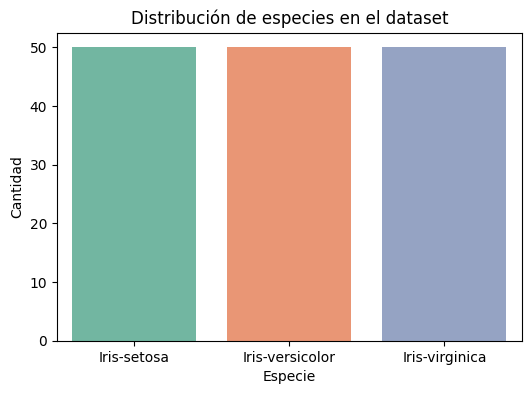

In [26]:
# Distribución de especies en el dataset
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Species", palette="Set2")

plt.title("Distribución de especies en el dataset")
plt.xlabel("Especie")
plt.ylabel("Cantidad")

plt.show()

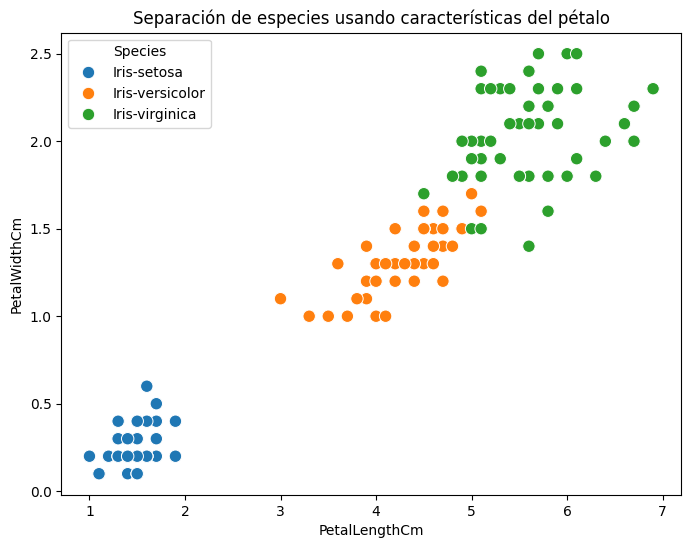

In [25]:
# Separación de clases del dataset

import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    s=80
)

plt.title("Separación de especies usando características del pétalo")

plt.show()

### Eliminación de la columna de ID

In [5]:
# Se elimina la columna ID del Dataframe ya que su única función es distinguir una fila de otra dentro del dataset, pero no representa ninguna característica
# física de la flor por lo que es información irrelevante para el modelo en su búsqueda por predecir la especie de la flor.
df = df.drop('Id', axis=1)
# Se realiza nuevamente una inspección rápida del DataFrame después de la eliminación de la columna Id.
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Revisión de valores nulos (NULL)

In [6]:
# Se revisa el dataset por medio de Dataframe para validar si existen valores faltantes en cada columna NaN (Not a Number) y saber si es necesario
# aplicar métodos de preprocesamiento antes del entrenamiento del modelo.
# La implementación estándar de LogisticRegression en scikit-learn no acepta valores faltantes y lanzaría un error.
df.isnull().sum()
# Se obtiene más información sobre el dataset a partir del Dataframe, antes de comenzar a entrenar el modelo (número de filas, número de columnas y
# tipos de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
# Se invoca al método describe del Dataframe, este método calcula un conjunto de estadísticas descriptivas para todas las columnas numéricas.
# Esto porque se quiere revisar el comportamiento estadístico de las variables (promedio, desviación estándar, mínimos, máximos, primer cuartil, mediana y
# tercer cuartil)
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Análisis de Correlación

In [8]:
# Calcula la correlación para las columnas numéricas, esto ayuda en el análisis a identificar variables altamente correlacionadas,
# comprender mejor la estructura de los datos y detectar posibles problemas de multicolinealidad que podrían afectar la interpretación del modelo.
df.corr(numeric_only=True)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


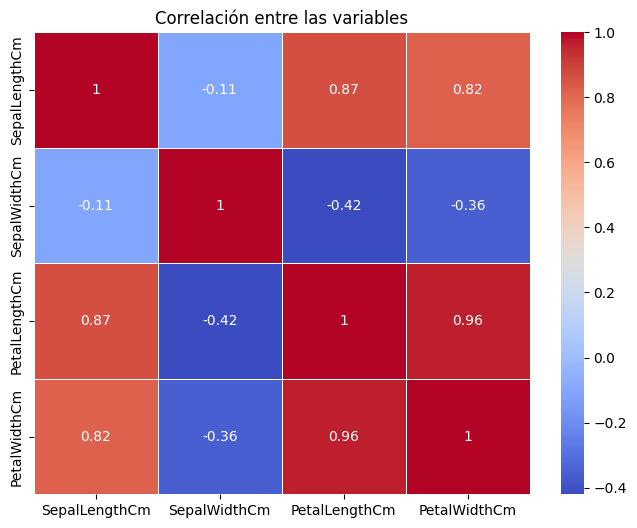

In [24]:
# Mapa de Calor de Correlación
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop(columns=["Species"]).corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlación entre las variables")

plt.show()

## Creación de modelos

In [9]:
# Se invoca el método de Pandas en el Dataframe para seleccionar filas y columnas utilizando indices númericos y no los nombres
# de las columnas(texto). Para este caso x representa los features (características), y representa el target (especie).
# Esto se realiza porque en el aprendizaje supervisado el modelo necesita distinguir calramente entre la información con la que
# aprenderá (features) y la respuesta correcta que intentará predecir (target)
x = df.iloc[:,0:4]
y = df.iloc[:,4:]

In [10]:
# Se realiza una inspección rápida para comprobar que la separación entre x y y fue correcta (aparecen sólo los features)
x.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
# Se realiza una inspección rápida para comprobar que la separación entre x y y fue correcta (aparecen sólo los targets)
y.head()

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


### Separación del dataset en features y targets

In [20]:
# Se importa la función train_test_split para dividir el dataset en dos subconjuntos Entrenamiento (Training Set) y Prueba (Test Set)
from sklearn.model_selection import train_test_split
# La función asigna a variables los subconjuntos generados del dataset
# x_train contiene las features que utilizará el modelo para el entrenamiento.
# y_train contiene los targets para los features de entrenamiento.
# x_test contiene las features que utilizará el modelo para la prueba.
# y_test contiene los targets para los features de prueba.
# El 33% del dataset se reserva para pruebas, manejando una proporción de aproximadamente 70% entrenamiento y 30% pruebas
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33, random_state=8)

## Implementación de la Regresión Logística

In [16]:
# Se invoca el modelo de regresión logistica y se asigna a la variable logr
logr = LogisticRegression(random_state=8)
# Se inicia la fase de entrenamiento para aprender los pesos que minimizan la función de costo
logr.fit(x_train,y_train.values.ravel())
# Se inicia la fase de predicción/inferencia donde el modelo ya no aprende ni modifica sus parámetros,
# siemplemente utiliza los pesos aprendidos en la etapa de entrenamiento para estimar la clase de nuevas observaciones.
y_pred = logr.predict(x_test)

## Evaluación del módelo

In [21]:
# Se calcula e imprime la métrica Accuracy (Exactitud)
accuracy_score_logr = accuracy_score(y_test,y_pred,normalize=True)
print("Accuracy Score : ",accuracy_score_logr)

Accuracy Score :  0.94


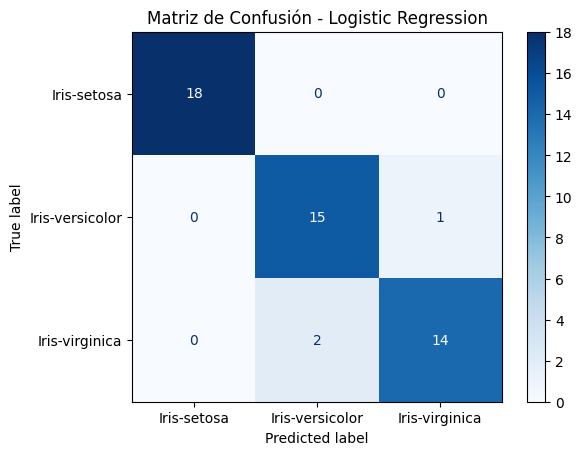

In [23]:
# Matriz de Confusión - Permite identificar no solamente cuántas predicciones fueron correctas, sino también en qué especies se equivoca el modelo.
# La diagonal principal representa las clasificaciones correctas, mientras que los valores fuera de la diagonal corresponden a errores de clasificación.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones del modelo
y_pred = logr.predict(x_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Graficar
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logr.classes_
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()
